In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image
from sklearn.ensemble import IsolationForest

%matplotlib inline

### Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

R. Se realizo una limpieza no muy profunda del dataframe, se eliminaron los datos nulos correspondientes a educm y act_fisica, se eliminaron los outliders de las variables edad, imce, educm, educp, fuera de los percentiles 1 y 99. 

In [ ]:
df = pd.read_csv("junaeb3.csv")
#df = pd.read_csv("../../data/junaeb3.csv")
df.describe()
df.dropna(inplace=True)

In [135]:
df.head()

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,1,1,1,4.0,0,8.0,8,-1
6,1,91,2.75,1,1,1,1,1,2,2,...,3,3,3,2,2,2.0,1,20.0,19,1


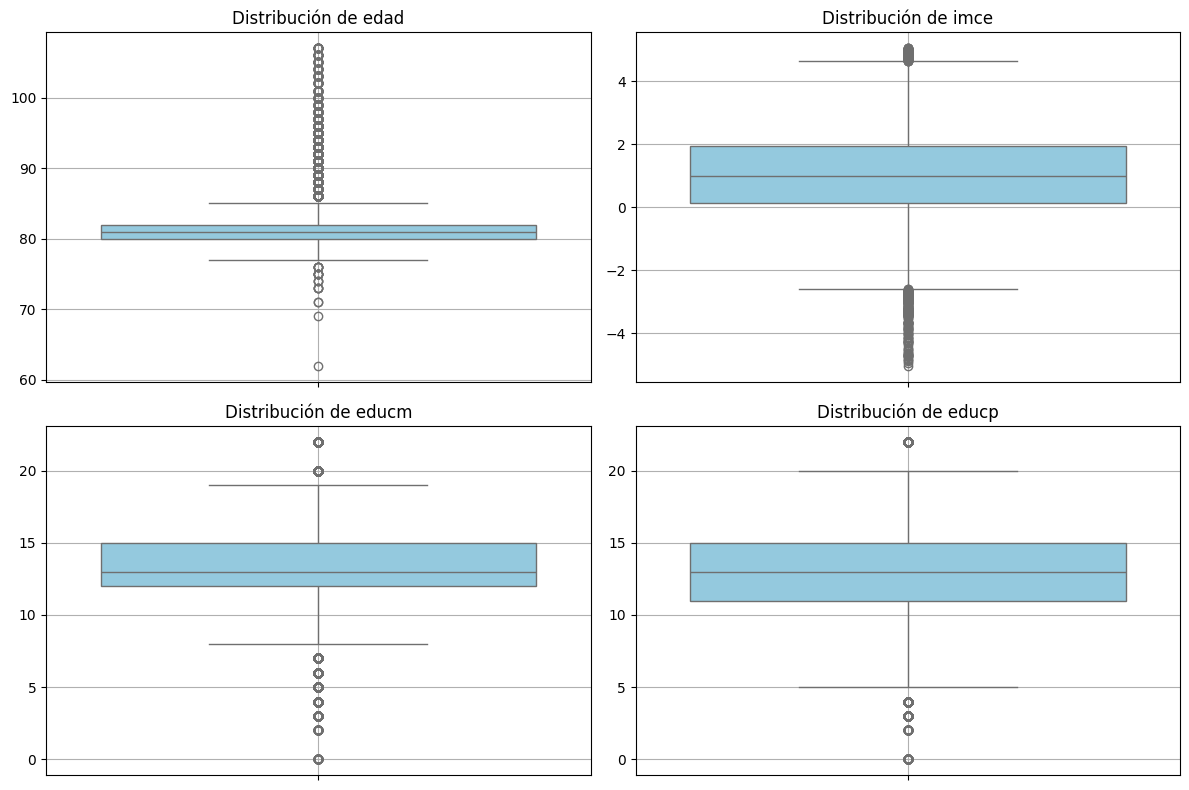

In [136]:
#df["sk7"] = 6 - df["sk7"]

columns = ["edad", "imce", "educm", "educp"]

# Crear una figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # Para iterar fácilmente

# Graficar cada boxplot en su subplot
for i, col in enumerate(columns):
    sns.boxplot(data=df, y=col, ax=axes[i], color="skyblue")
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

for col in columns:
    Q1 = df[col].quantile(0.01)
    Q3 = df[col].quantile(0.99)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

### A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

R. se realizo el analisis factorial a partir de las variables sk#, dando un numero optimo de factores de 4, observado con el metodo del codo y el criterio de kaiser, corroborando además con los valores propios obtenidos.  
Al correr el modelo con los 4 factores se observo que ninguna variable quedo clasificada en el factor 4, por lo que se optó por realizar el analisis factorial con 3 factores. Dando los siguientes factores: 
 
Factor 0: sk9, sk10, sk11, sk12, sk13.  
Factor 1: sk5, sk6, sk8.  
Factor 2: sk1, sk2, sk3, sk4.  

Se obtuvo además la precencia de una variable no informativa, la cual es sk7, o sea que no aporta diferenciacion al modelo. Se opto por no eliminarla, pero sí no considerarla en los modelos de más adelante.

In [137]:
df1=df[["sk1","sk2","sk3","sk4","sk5","sk6","sk7","sk8","sk9","sk10","sk11","sk12","sk13"]]

[4.03413953 1.35090534 1.11485807 1.00134278 0.79124572 0.70703254
 0.70143026 0.69062958 0.60818266 0.52937922 0.51717186 0.49139734
 0.46228509]


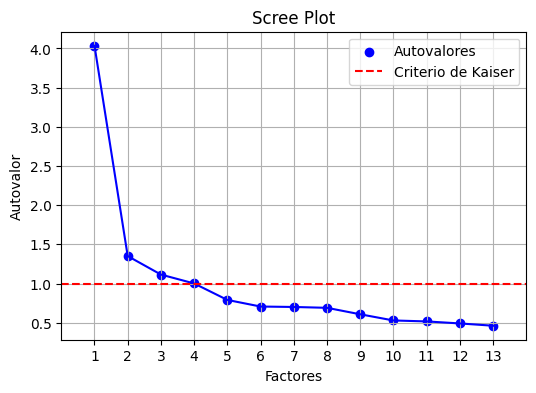

In [138]:
fa = FactorAnalyzer(rotation='varimax').fit(df1)
eigenvalues, _ = fa.get_eigenvalues()
print(eigenvalues)
# Gráfico Scree Plot mejorado
plt.figure(figsize=(6,4))
plt.scatter(range(1, len(eigenvalues)+1), eigenvalues, marker='o', color='blue', label='Autovalores')
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, linestyle='-', color='blue')
plt.axhline(y=1, color='r', linestyle='--', label='Criterio de Kaiser')
plt.xlim(0, len(eigenvalues)+1)
plt.xticks(range(1, len(eigenvalues)+1))
plt.title('Scree Plot')
plt.xlabel('Factores')
plt.ylabel('Autovalor')
plt.legend()
plt.grid()
plt.show()


In [139]:
df.head()

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,1,5.0,0,8.0,8,1
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1,1.0,1,17.0,15,0
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,1,1,1,4.0,0,8.0,8,-1
6,1,91,2.75,1,1,1,1,1,2,2,...,3,3,3,2,2,2.0,1,20.0,19,1


In [140]:
# Número óptimo de factores (ajusta según el scree plot)
n_factores = 4

# EFA con rotación oblicua (más realista en ciencias sociales)
fa = FactorAnalyzer(n_factors=n_factores, rotation='varimax')
fa.fit(df1)

# Cargas factoriales
loadings = pd.DataFrame(fa.loadings_, index=df1.columns)
print(loadings)

             0         1         2         3
sk1   0.166128  0.511090  0.052652  0.328585
sk2   0.171904  0.477756  0.259393  0.375734
sk3   0.195550  0.624919  0.167856 -0.029963
sk4   0.213114  0.695136  0.186827  0.042479
sk5   0.136428  0.221913  0.735058  0.130655
sk6   0.167491  0.170708  0.416068  0.309636
sk7   0.061279  0.027143  0.069787  0.297614
sk8   0.286111  0.109182  0.465550  0.070280
sk9   0.507096  0.205292  0.187352  0.039018
sk10  0.559343  0.089620  0.069369  0.176771
sk11  0.668379  0.191411  0.162631  0.120238
sk12  0.529626  0.108118  0.128585  0.028754
sk13  0.482579  0.139101  0.102800  0.087250


In [141]:
# Umbral mínimo de carga
threshold = 0.3

# Ver variables con todas las cargas por debajo del umbral
uninformative_vars = loadings[(loadings.abs() < threshold).all(axis=1)]
print("Variables no informativas:\n", uninformative_vars)

Variables no informativas:
             0         1         2         3
sk7  0.061279  0.027143  0.069787  0.297614


In [142]:
# Varianza explicada por cada factor
var_exp = fa.get_factor_variance()
print("Varianza explicada:\n", var_exp)

Varianza explicada:
 (array([1.80321476, 1.57209866, 1.16163146, 0.51397152]), array([0.13870883, 0.12093067, 0.08935627, 0.03953627]), array([0.13870883, 0.25963949, 0.34899576, 0.38853203]))


Factor 0: sk13,sk12,sk11,sk10,sk9  
Factor 1: sk1,sk2,sk3,sk4  
Factor 2: sk5,sk6,sk8  
Factor 3: ninguna  
  
Debido a que hay un factor con ninguna variable se realizara el EFA con 3 factores 

In [143]:
# Número óptimo de factores (ajusta según el scree plot)
n_factores = 3

# EFA con rotación oblicua (más realista en ciencias sociales)
fa = FactorAnalyzer(n_factors=n_factores, rotation='varimax')
fa.fit(df1)

# Cargas factoriales
loadings = pd.DataFrame(fa.loadings_, index=df1.columns)
print(loadings)

             0         1         2
sk1   0.171221  0.540217  0.151458
sk2   0.174149  0.512531  0.354330
sk3   0.179785  0.587108  0.161938
sk4   0.195805  0.685256  0.194526
sk5   0.121301  0.214133  0.716727
sk6   0.162524  0.203313  0.486711
sk7   0.070301  0.074530  0.146613
sk8   0.269211  0.097481  0.478541
sk9   0.495887  0.205273  0.201636
sk10  0.555989  0.121166  0.127875
sk11  0.665920  0.206954  0.202009
sk12  0.524127  0.109526  0.141501
sk13  0.480548  0.151480  0.131725


Factor 0: sk9, sk10, sk11, sk12, sk13.  
Factor 1: sk5, sk6, sk8.  
Factor 2: sk1, sk2, sk3, sk4.  

### Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

R. A partir de los factores creados anteriormente se extrajo la puntuación factorial de cada observación presente en la data, se concatenó las columnas obtenidas a una copia del df original y se plotearon los graficos.  
El análisis visual de estos gráficos reveló que no existen diferencias significativas en la distribución de las puntuaciones factoriales entre los distintos grupos analizados. La ausencia de una separación clara o patrones diferenciados indica que los factores extraídos no discriminan efectivamente entre los grupos estudiados. Esto sugiere que las variables originales utilizadas para agrupar las observaciones no se reflejan en la estructura factorial encontrada, o que dichas agrupaciones no afectan sustancialmente la variabilidad explicada por los factores.

In [144]:
factor_scores = fa.transform(df1)
efa_df = pd.DataFrame(data=factor_scores,columns=[f'F{i+1}' for i in range(n_factores)])
df2 = pd.merge(df,efa_df,left_index=True, right_index=True)
df2.head()

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk12,sk13,act_fisica,area,educm,educp,madre_work,F1,F2,F3
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,5.0,0,8.0,8,1,-0.708078,-0.316767,-0.485394
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,2.0,1,16.0,12,-1,-0.787695,0.018257,-0.246966
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1.0,1,17.0,15,0,1.759304,-0.071659,0.816447
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,4.0,0,8.0,8,-1,1.945484,-0.574066,2.925033
6,1,91,2.75,1,1,1,1,1,2,2,...,2,2,2.0,1,20.0,19,1,1.634104,1.416207,-0.477916


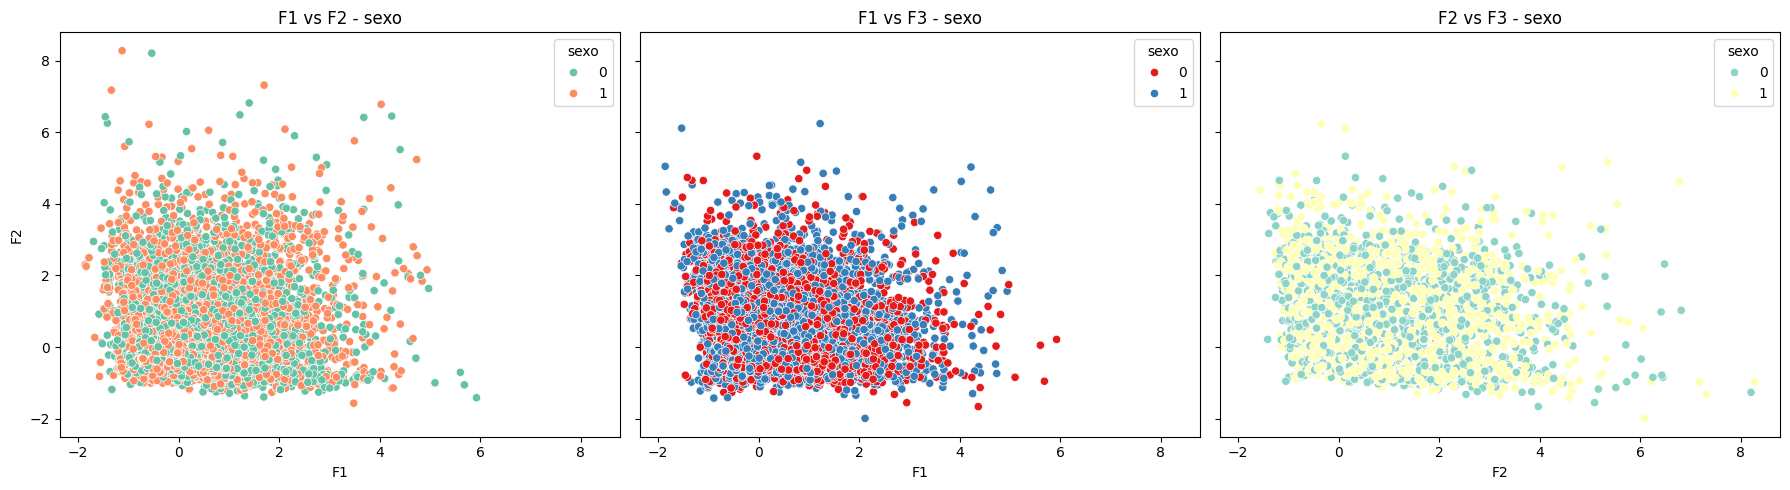

In [145]:
# Crear figura con 3 subplots horizontales
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# 1. F1 vs F2 coloreado por sexo
sns.scatterplot(data=df2, x='F1', y='F2', hue='sexo', ax=axes[0], palette='Set2')
axes[0].set_title('F1 vs F2 - sexo')

# 2. F1 vs F2 coloreado por área
sns.scatterplot(data=df2, x='F1', y='F3', hue='sexo', ax=axes[1], palette='Set1')
axes[1].set_title('F1 vs F3 - sexo')

# 3. F1 vs F2 coloreado por actividad física
sns.scatterplot(data=df2, x='F2', y='F3', hue='sexo', ax=axes[2], palette='Set3')
axes[2].set_title('F2 vs F3 - sexo')

# Ajustar espacio
plt.tight_layout()
plt.show()

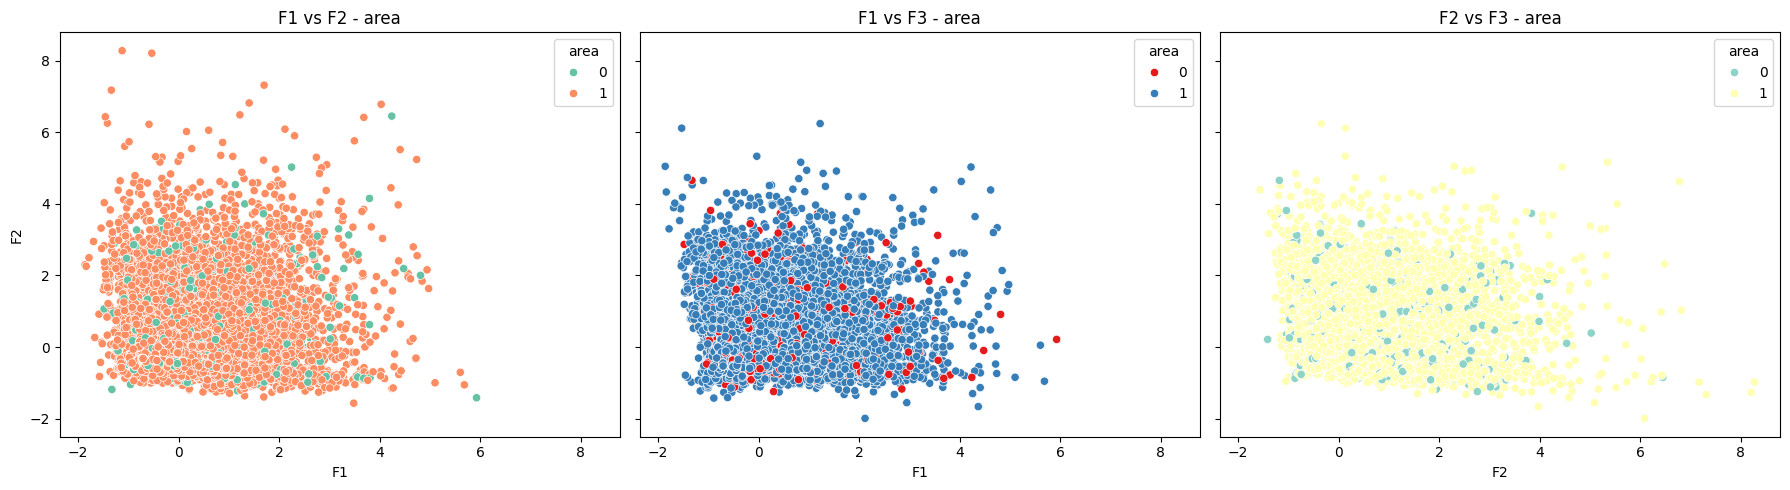

In [146]:
# Crear figura con 3 subplots horizontales
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# 1. F1 vs F2 coloreado por sexo
sns.scatterplot(data=df2, x='F1', y='F2', hue='area', ax=axes[0], palette='Set2')
axes[0].set_title('F1 vs F2 - area')

# 2. F1 vs F2 coloreado por área
sns.scatterplot(data=df2, x='F1', y='F3', hue='area', ax=axes[1], palette='Set1')
axes[1].set_title('F1 vs F3 - area')

# 3. F1 vs F2 coloreado por actividad física
sns.scatterplot(data=df2, x='F2', y='F3', hue='area', ax=axes[2], palette='Set3')
axes[2].set_title('F2 vs F3 - area')

# Ajustar espacio
plt.tight_layout()
plt.show()

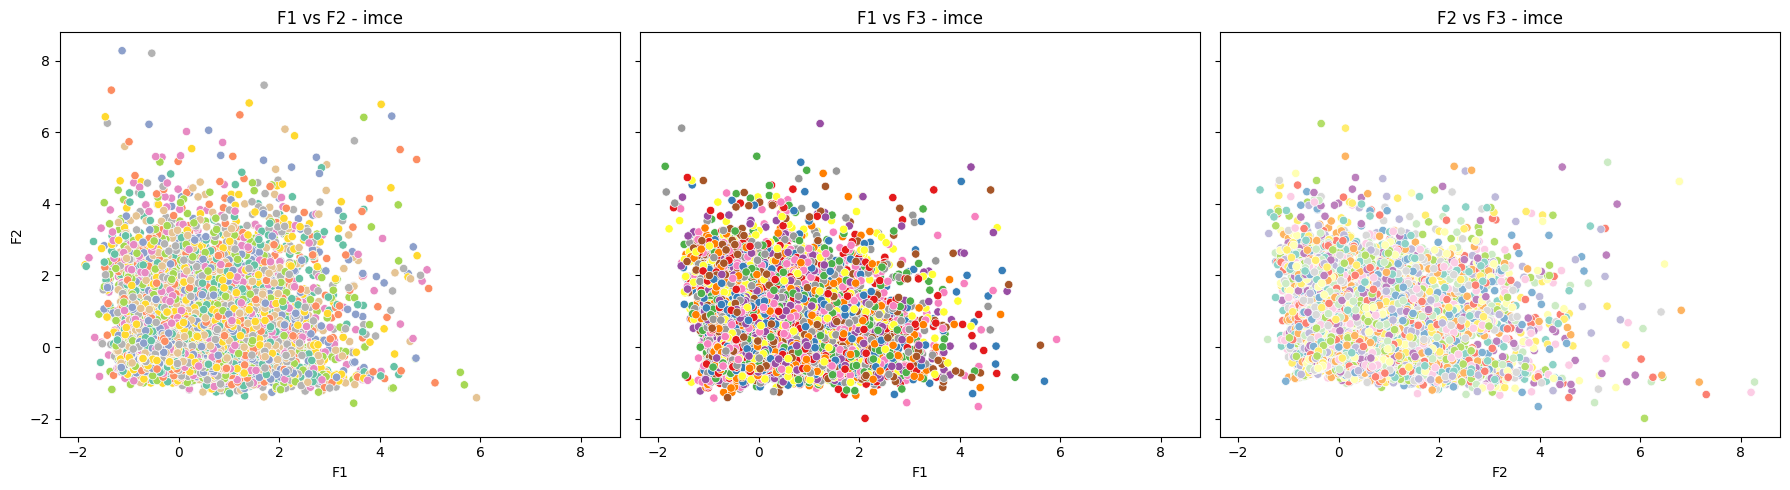

In [147]:
# Crear figura con 3 subplots horizontales
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# 1. F1 vs F2 coloreado por sexo
sns.scatterplot(data=df2, x='F1', y='F2', hue='imce', ax=axes[0], palette='Set2')
axes[0].set_title('F1 vs F2 - imce')
axes[0].legend_.remove()

# 2. F1 vs F2 coloreado por área
sns.scatterplot(data=df2, x='F1', y='F3', hue='imce', ax=axes[1], palette='Set1')
axes[1].set_title('F1 vs F3 - imce')
axes[1].legend_.remove()

# 3. F1 vs F2 coloreado por actividad física
sns.scatterplot(data=df2, x='F2', y='F3', hue='imce', ax=axes[2], palette='Set3')
axes[2].set_title('F2 vs F3 - imce')
axes[2].legend_.remove()

# Ajustar espacio
plt.tight_layout()
plt.show()

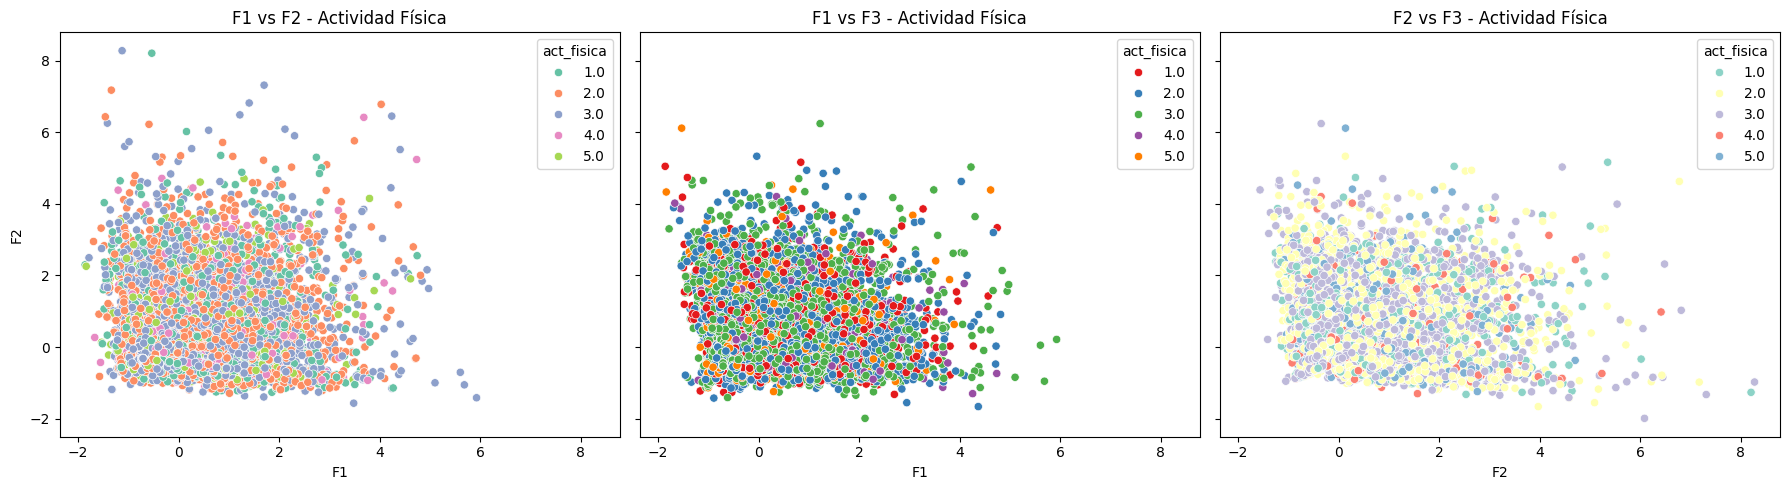

In [148]:
# Crear figura con 3 subplots horizontales
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# 1. F1 vs F2 coloreado por sexo
sns.scatterplot(data=df2, x='F1', y='F2', hue='act_fisica', ax=axes[0], palette='Set2')
axes[0].set_title('F1 vs F2 - Actividad Física')

# 2. F1 vs F2 coloreado por área
sns.scatterplot(data=df2, x='F1', y='F3', hue='act_fisica', ax=axes[1], palette='Set1')
axes[1].set_title('F1 vs F3 - Actividad Física')

# 3. F1 vs F2 coloreado por actividad física
sns.scatterplot(data=df2, x='F2', y='F3', hue='act_fisica', ax=axes[2], palette='Set3')
axes[2].set_title('F2 vs F3 - Actividad Física')

# Ajustar espacio
plt.tight_layout()
plt.show()

### Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings).

R. A partir de los factores anteriores se realizo un modelo CFA segun la agrupacion obtenida, se asigno un nombre a cada factor de la siguiente manera:  
  
Curiosidad con las variables sk9 hasta sk13. Tiene este nombre debido a que este set de preguntas abarca temas sobre distintos aspectos del interés y la exploración activa del entorno, características fundamentales del constructo de curiosidad.  
Relaciones con las variables sk5, sk6 y sk8. Este set tiene como foco la interacción con otros.  
Expresividad con las variables sk1 a sk4. Tiene este nombre debido a que este set busca evaluar la manera de manifestar sus emociones y sentimientos hacia los demás, lo cual es la esencia del constructo de expresividad emocional.  
  
Al analizar el modelo se puede observar que todas las variables son significativas, contribuyen a medir el factor, las principales variables por cada factor son:  

- sk10 en curiosidad en relacion a la variable sk9, con un valor de 1.3  
- sk8 en relaciones comparandolo con sk5 como factor, base con un valor de 1.15  
- sk2 en expresividad en relacion a la variable sk1, con un valor de 1.87  

Vemos además que los factores son significativos y con varianzas positivas, la covarianza del factor curiosidad es el menor de los 3, posiblemente por que los individuos puntuan similar en ese factor.


In [149]:
modelo = """
Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13  
Relaciones =~ sk5 + sk6 + sk8
expresividad =~  sk1 + sk2 + sk3 + sk4
"""

model=semopy.Model(modelo)
out=model.fit(df)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.143
Number of iterations: 41
Params: 1.348 1.248 1.097 1.274 1.020 1.158 1.877 1.646 1.846 0.152 0.091 0.051 0.161 0.057 0.049 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.372 0.469 0.277


In [150]:
print(model.inspect(mode='list', what="names", std_est=True))

            lval  op          rval  Estimate  Est. Std  Std. Err     z-value  \
0            sk9   ~    Curiosidad  1.000000  0.594425         -           -   
1           sk10   ~    Curiosidad  1.348296  0.562596   0.01854   72.725071   
2           sk11   ~    Curiosidad  1.247906  0.736003  0.014736   84.684717   
3           sk12   ~    Curiosidad  1.097330  0.540702  0.015523   70.692694   
4           sk13   ~    Curiosidad  1.273586  0.506374  0.018913   67.339241   
5            sk5   ~    Relaciones  1.000000  0.718118         -           -   
6            sk6   ~    Relaciones  1.019985  0.556582   0.01433   71.178266   
7            sk8   ~    Relaciones  1.158490  0.560988  0.016193   71.542093   
8            sk1   ~  expresividad  1.000000  0.582652         -           -   
9            sk2   ~  expresividad  1.876642  0.644548  0.023793    78.87212   
10           sk3   ~  expresividad  1.646084  0.631816  0.021121   77.934883   
11           sk4   ~  expresividad  1.84

In [151]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4252.869542,0.0,80903.16637,0.948021,0.947433,0.931972,0.947433,0.932733,0.052674,53.713573,277.780299,0.143214


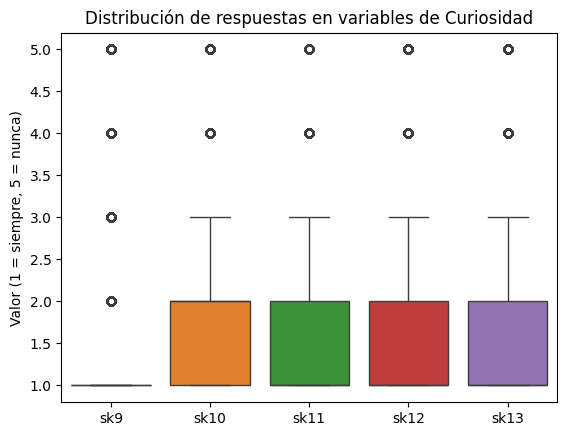

In [152]:
vars_curiosidad = ['sk9', 'sk10', 'sk11', 'sk12', 'sk13']
sns.boxplot(data=df[vars_curiosidad])
plt.title("Distribución de respuestas en variables de Curiosidad")
plt.ylabel("Valor (1 = siempre, 5 = nunca)")
plt.show()

### Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

R. Para determinar el número óptimo de clústeres, se llevó a cabo una iteración de modelos considerando entre 2 y 10 componentes. La evaluación se basó en el criterio de información bayesiano (BIC), el cual penaliza la complejidad del modelo para evitar sobreajuste. Según este criterio, el valor óptimo se alcanzó con 4 clústeres, lo que inicialmente se tomó como punto de partida para el análisis.

Sin embargo, al examinar los resultados del modelo con 4 clústeres, se observó que el cuarto clúster (Cluster 3) presentaba un peso muy bajo, es decir, agrupaba a un número muy reducido de observaciones. Además, los límites entre los grupos mostraban una alta superposición, lo que dificultaba una separación clara entre categorías.

En función de estos hallazgos, se optó por ajustar el modelo a 3 clústeres, priorizando una segmentación más representativa y robusta de la muestra. Con este nuevo agrupamiento, se identificaron patrones más consistentes y significativos, lo que permitió proponer una posible interpretación de los grupos:

Clúster 0: Personas con características compatibles con desnutrición o bajo peso.

Clúster 1: Personas con sobrepeso.

Clúster 2: Personas con valores dentro de rangos saludables.

Fitting StepMix...


Initializations (n_init) :   0%|          | 0/1 [00:00<?, ?it/s]

Initializations (n_init) : 100%|██████████| 1/1 [00:02<00:00,  2.57s/it, max_LL=-5.18e+4, max_avg_LL=-1.74]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:07<00:00,  7.15s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:30<00:00, 30.16s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]
c:\Users\jano7\AppData\Local\Programs\Python\Python312\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:34<00:00, 34.97s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]
c:\Users\jano7\AppData\Local\Programs\Python\Python312\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


<Axes: >

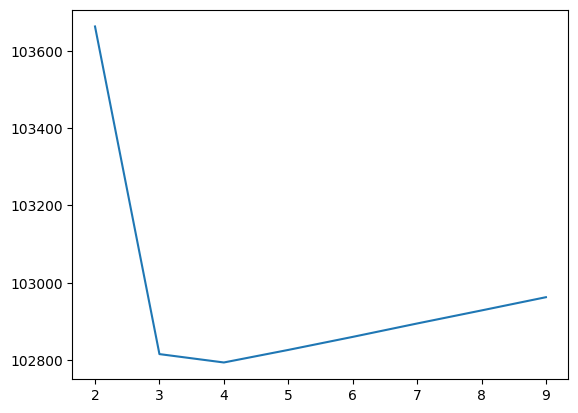

In [153]:
from stepmix.stepmix import StepMix
# Numero optimo de clusters
K = range(2, 10)
fits = []
BIC = []
df3=df[['imce']]

for k in K:
    # train the model for current value of k on training data
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(df3)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    BIC.append(model.sabic(df3))

sns.lineplot(x = K, y = BIC)  

In [154]:
model2 = StepMix(n_components=4, measurement="gaussian", verbose=1, random_state=123)
# Fit model and predict clusters
model2.fit(df3)
df['pred']=model2.predict(df3)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:18<00:00, 18.05s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                        
          class_no                   0       1       2       3
          param variable                                      
          means imce             1.173  2.7111 -2.5822  0.1384
    Class weights
        Class 1 : 0.49
        Class 2 : 0.16
        Class 3 : 0.01
        Class 4 : 0.35
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 4
    Number of estimated parameters: 7
    Log-likelihood (LL)           : -51336.0764
    -2LL                          : 102672.1527
    Average LL                    : -1.7287
    AIC                           : 102686.15
    BIC                           : 102744.24
    CAIC                          : 102751.24
    Sample-Size Adjusted BIC      : 102794.09
    Entropy                       : 22265.7966
    Scaled Relative Entropy    


c:\Users\jano7\AppData\Local\Programs\Python\Python312\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


C:\Users\jano7\AppData\Local\Temp\ipykernel_31176\3517496670.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='pred', y='imce', data=df, jitter=True, palette='Set2')


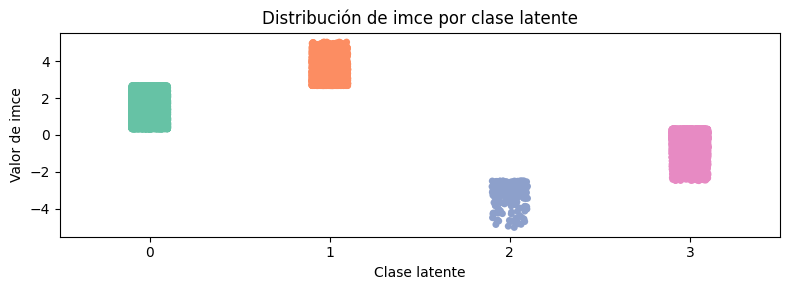

In [155]:
plt.figure(figsize=(8, 3))
sns.stripplot(x='pred', y='imce', data=df, jitter=True, palette='Set2')
plt.title('Distribución de imce por clase latente')
plt.xlabel('Clase latente')
plt.ylabel('Valor de imce')
plt.tight_layout()
plt.show()

In [156]:
model2 = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)
# Fit model and predict clusters
model2.fit(df3)
df['pred']=model2.predict(df3)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:06<00:00,  6.62s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            -1.949  2.4056  0.5984
    Class weights
        Class 1 : 0.02
        Class 2 : 0.27
        Class 3 : 0.71
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -51364.3251
    -2LL                          : 102728.6503
    Average LL                    : -1.7297
    AIC                           : 102738.65
    BIC                           : 102780.14
    CAIC                          : 102785.14
    Sample-Size Adjusted BIC      : 102815.75
    Entropy                       : 11499.4902
    Scaled Relative Entropy       : 0.6475


C:\Users\jano7\AppData\Local\Temp\ipykernel_31176\3517496670.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='pred', y='imce', data=df, jitter=True, palette='Set2')


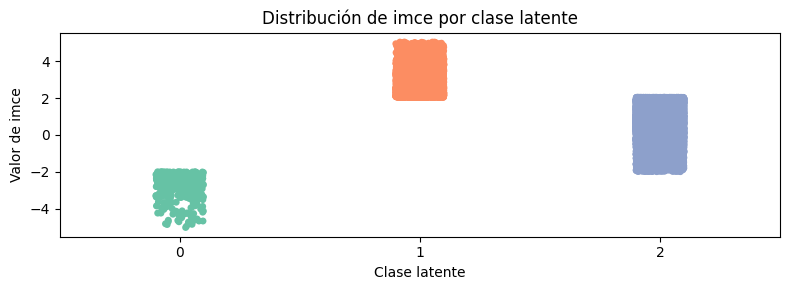

In [157]:
plt.figure(figsize=(8, 3))
sns.stripplot(x='pred', y='imce', data=df, jitter=True, palette='Set2')
plt.title('Distribución de imce por clase latente')
plt.xlabel('Clase latente')
plt.ylabel('Valor de imce')
plt.tight_layout()
plt.show()

### Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

R. Se realizo un grafico de correlaciones entre variables para observar si existia una fuerte correlación, pero no fue el caso, se opto entonces por un modelo con todas las variables y se fue iterando hasta encontrar un modelo optimo sin las variables vive_padre y vive_madre, las cuales no fueron significativas en ningun modelo, se opto además por la creacion de una nueva variable ActFisicaGrupal relacionandola con sk8 y act_fisica, esto con el sentido de que jugar en grupo puede ser una forma de actividad física. El modelo arrojo un TLI de 0.896(cercano a 1), un RMSEA de 0.043(<0,05) y un CFI de 0.91(cercano a 1), en general estos valores demuestran que es un buen modelo.   
En cuanto a las variables se puede destacar los siguientes puntos:  
- La relación imce ~ Relaciones no es significativa, los datos de relaciones no aportan suficiente evidencia para afirmar que existe un efecto en torno al indice de masa corporal.  
- Todas las variables son significativas.  
- Curiosidad y expresividad tienen un efecto negativo sobre el indice de masa corporal, un aumento de 1u de la variable latente se asocia con una disminucion en 0.091 u y 0.18 de imc, respectivamente.
- La incorporacion de la variable ActFisicaGrupal tiene un efecto significativo en el modelo, aun cuando relaciones no la tuvo, con un efecto de 0.2 puntos en imce, lo cual indica que si tiene menos actividad aumentan 0.2 puntos su indice de masa corporal.  
- Si la madre trabaja aumenta en 0.045 el imc, posiblemente por que el niño no comerá de la mejor manera, posiblemente comida rapida o de no tan buena calidad como la casera.

<Axes: >

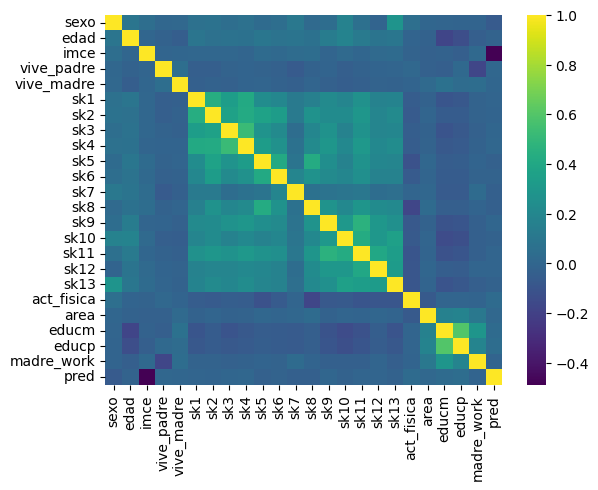

In [158]:
sns.heatmap(df.corr(), cmap='viridis')

In [159]:
df["act_fisica_inv"]= 6 - df["act_fisica"]

In [160]:
modelo_est = """
#Measurement

Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13  
Relaciones =~ sk5 + sk6 + sk8
expresividad =~  sk1 + sk2 + sk3 + sk4
ActFisicaGrupal =~ sk8 + act_fisica_inv

#Structural

imce ~ Curiosidad + Relaciones + expresividad + sexo + edad + area + ActFisicaGrupal + educm + educp + madre_work

"""
model_cfa = semopy.Model(modelo_est)
out = model_cfa.fit(df)
print(out)


Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.318
Number of iterations: 76
Params: 1.343 1.243 1.098 1.275 0.993 0.496 1.878 1.644 1.847 0.637 -0.091 0.073 -0.183 0.138 -0.005 -0.131 0.208 -0.006 -0.014 0.046 0.197 0.101 0.030 0.152 0.090 0.085 0.051 0.169 0.060 1.061 0.049 1.856 0.095 0.596 0.201 0.441 0.712 0.242 0.199 0.158 0.143 0.373 0.346 0.277


In [161]:
semopy.calc_stats(model_cfa)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,166,196,9456.018745,0.0,106151.421131,0.912321,0.91092,0.894821,0.91092,0.896476,0.043412,87.363145,452.508921,0.318427


In [162]:
print(model_cfa.inspect())

               lval  op             rval  Estimate  Std. Err     z-value  \
0               sk9   ~       Curiosidad  1.000000         -           -   
1              sk10   ~       Curiosidad  1.342796   0.01843   72.858233   
2              sk11   ~       Curiosidad  1.243200  0.014609   85.099322   
3              sk12   ~       Curiosidad  1.097715  0.015455   71.027478   
4              sk13   ~       Curiosidad  1.275278  0.018837   67.701916   
5               sk5   ~       Relaciones  1.000000         -           -   
6               sk6   ~       Relaciones  0.993288  0.014316   69.381733   
7               sk8   ~       Relaciones  0.496499  0.062882    7.895751   
8               sk8   ~  ActFisicaGrupal  1.000000         -           -   
9               sk1   ~     expresividad  1.000000         -           -   
10              sk2   ~     expresividad  1.877592  0.023769   78.992665   
11              sk3   ~     expresividad  1.644433  0.021087   77.982435   
12          

R.

7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?

In [167]:
df["pred"].value_counts()

pred
2    22603
1     6679
0      414
Name: count, dtype: int64

R. El modelo al estimarlo por factores genera que se vean los efectos de las variables dependiendo del grupo, lo que permite un analisis mas detallado del impacto de las variables.  
Se obtuvo los siguientes resultados:  
- Clase "sano" = 2, presenta 6 variables no significativas: curiosidad, relaciones, expresividad, sexo, ActFisicaGrupal y educm. Es el modelo más informativo y solido estadisticamente, esto proveniente de la cantidad de datos pertenecientes a este grupo.
- Clase "sobrepeso" tiene no significativa 5 variables: relaciones, expresividad, area, educp, madrework.
- Clase "desnutricion tiene tiene significativas solo 2 variables: ActFisicaGrupal y educm. Es el modelo menos preciso, ocacionado por tener muy poca poblacion en este grupo.

Se observa además que cada grupo tiene carga diferente en las variables en relacion a imce. Por ejemplo:     
............GRUPO 2 GRUPO 1 GRUPO 0  
Curiosidad	-0.016	-0.113	0.061    
Relaciones	0.012	-0.037	-0.066  
Expresividad	-0.064	-0.005	0.516  

In [163]:
CL0 = df[df["pred"] == 0]
CL1 = df[df["pred"] == 1]
CL2 = df[df["pred"] == 2]

# Crear un modelo nuevo para cada clase
model0 = semopy.Model(modelo_est)
model1 = semopy.Model(modelo_est)
model2 = semopy.Model(modelo_est)

# Ajustar cada modelo a su subconjunto
out0 = model0.fit(CL0)
out1 = model1.fit(CL1)
out2 = model2.fit(CL2)

params0 = model0.inspect()
params1 = model1.inspect()
params2 = model2.inspect()

In [164]:
print(params0)

               lval  op             rval  Estimate  Std. Err    z-value  \
0               sk9   ~       Curiosidad  1.000000         -          -   
1              sk10   ~       Curiosidad  1.020396  0.117222   8.704784   
2              sk11   ~       Curiosidad  1.093665  0.096251  11.362659   
3              sk12   ~       Curiosidad  0.815264   0.08839   9.223463   
4              sk13   ~       Curiosidad  1.059279  0.124298   8.522091   
5               sk5   ~       Relaciones  1.000000         -          -   
6               sk6   ~       Relaciones  1.082219  0.130133   8.316253   
7               sk8   ~       Relaciones  0.941181  0.218649   4.304531   
8               sk8   ~  ActFisicaGrupal  1.000000         -          -   
9               sk1   ~     expresividad  1.000000         -          -   
10              sk2   ~     expresividad  2.474226  0.289791   8.537969   
11              sk3   ~     expresividad  2.203835  0.259636   8.488166   
12              sk4   ~  

In [165]:
print(params1)

               lval  op             rval  Estimate  Std. Err    z-value  \
0               sk9   ~       Curiosidad  1.000000         -          -   
1              sk10   ~       Curiosidad  1.367095   0.03899  35.062941   
2              sk11   ~       Curiosidad  1.237895   0.03032  40.827078   
3              sk12   ~       Curiosidad  1.146954  0.033233  34.512137   
4              sk13   ~       Curiosidad  1.366952  0.040707  33.580672   
5               sk5   ~       Relaciones  1.000000         -          -   
6               sk6   ~       Relaciones  0.942680  0.028875  32.647133   
7               sk8   ~       Relaciones  0.353370  0.131745   2.682219   
8               sk8   ~  ActFisicaGrupal  1.000000         -          -   
9               sk1   ~     expresividad  1.000000         -          -   
10              sk2   ~     expresividad  1.808264  0.046396  38.974165   
11              sk3   ~     expresividad  1.483002  0.040067  37.012865   
12              sk4   ~  

In [166]:
print(params2)

               lval  op             rval  Estimate  Std. Err     z-value  \
0               sk9   ~       Curiosidad  1.000000         -           -   
1              sk10   ~       Curiosidad  1.337605  0.021156   63.226346   
2              sk11   ~       Curiosidad  1.246562  0.016872   73.885175   
3              sk12   ~       Curiosidad  1.086885  0.017689   61.443697   
4              sk13   ~       Curiosidad  1.247472   0.02146   58.131015   
5               sk5   ~       Relaciones  1.000000         -           -   
6               sk6   ~       Relaciones  1.008594  0.016653   60.566655   
7               sk8   ~       Relaciones  0.519998  0.076068    6.835936   
8               sk8   ~  ActFisicaGrupal  1.000000         -           -   
9               sk1   ~     expresividad  1.000000         -           -   
10              sk2   ~     expresividad  1.893411  0.027777   68.164586   
11              sk3   ~     expresividad  1.691820   0.02487   68.026656   
12          